# Session 2 — Closing Discussion: Sharing Models with Clients

> *No code required — this is a consulting architecture discussion to close out the workshop.*

Over the past two sessions you've built, tested, registered, deployed, monitored, and operationalized a production-grade churn model. The engagement is wrapping up. Now the client asks: **"How do we actually get access to this model?"**

There's no single right answer — the best approach depends on the client's technical maturity, data residency requirements, and whether the engagement is a one-time delivery or an ongoing relationship.

This notebook walks through six delivery options, with the practical auth requirements for each.

---

## Option 1: Export the model artifact (pickle / MLflow)

Send the serialized model as a file. The client loads it in their own Python environment.

- **Auth required:** None — it's a file transfer (email, S3, shared drive)
- **Pros:** Zero infrastructure dependency; works anywhere Python runs
- **Cons:** No governance or monitoring once it leaves your hands; tightly coupled to exact Python/library versions; client must build their own serving layer; pickle files execute arbitrary code on load — a real security concern
- **Best for:** Quick one-time handoffs to technically sophisticated clients; internal team transfers

MLflow export is a step up from raw pickle — it bundles the conda environment and model signature — but the client still needs MLflow to load it and must manage serving themselves.


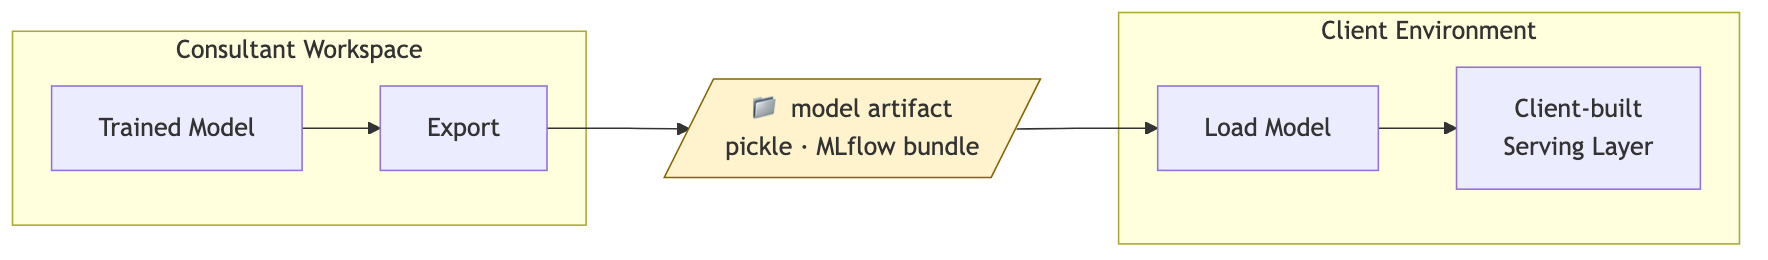

---

## Option 2: REST API (model serving endpoint)

You keep the model running on Databricks; the client calls it over HTTP.

- **Auth required:** Bearer token only — **the client does not need a Databricks account**. You provision a service principal in your workspace, grant it `CAN_QUERY` on the endpoint, and share its OAuth token. The client drops it in an HTTP `Authorization` header. Revocation is instant — delete the SP or rotate the token.
- **Pros:** You retain full control; AI Gateway adds rate limiting, request logging, and guardrails; client integration is a single HTTP call in any language; the `@champion` alias means you can silently promote new model versions without the client changing anything
- **Cons:** **Client data leaves their environment** — a hard blocker in many regulated industries; you own the uptime SLA and ongoing compute cost; the client has a dependency on your platform after the engagement closes
- **Best for:** Ongoing retainer relationships; SaaS-style delivery; clients not ready to operate the model themselves


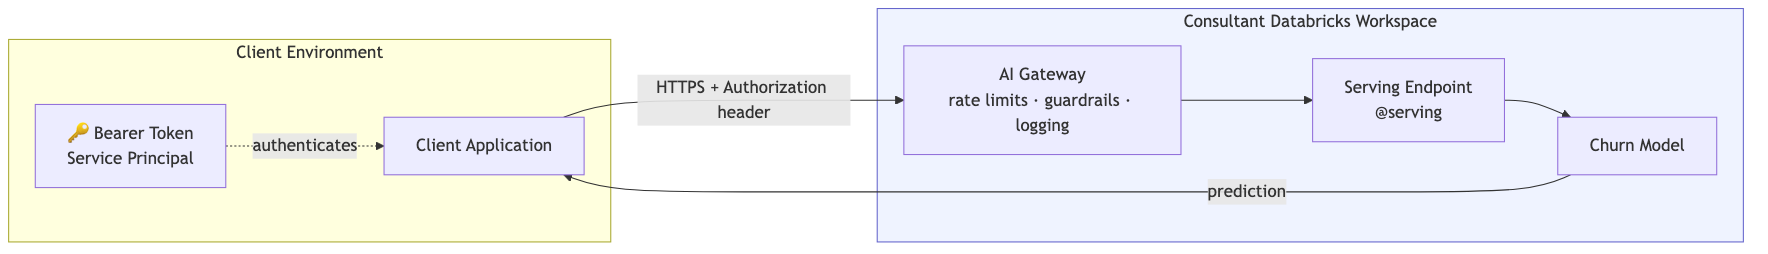

---

## Option 3: Delta Sharing

Share the MLflow model artifacts — stored in a Unity Catalog Volume — using the Delta Sharing open protocol.

- **Auth required:** A Delta Sharing **credential file** (bearer token + endpoint URL) — completely decoupled from Databricks workspace login. If the client is also a Databricks customer, you can use a cleaner UC-to-UC recipient setup with no credential file at all.
- **Pros:** Governed and revocable; works cross-cloud and cross-organization; client loads the model into *their* environment so **their data never leaves**; open protocol with broad tool support (Python, Spark, Power BI, etc.)
- **Cons:** Relatively new for model artifacts specifically; client still needs to build their own serving infrastructure; less commonly set up in practice today
- **Best for:** Regulated industries (financial services, healthcare) where data residency is a hard requirement; Databricks-to-Databricks engagements


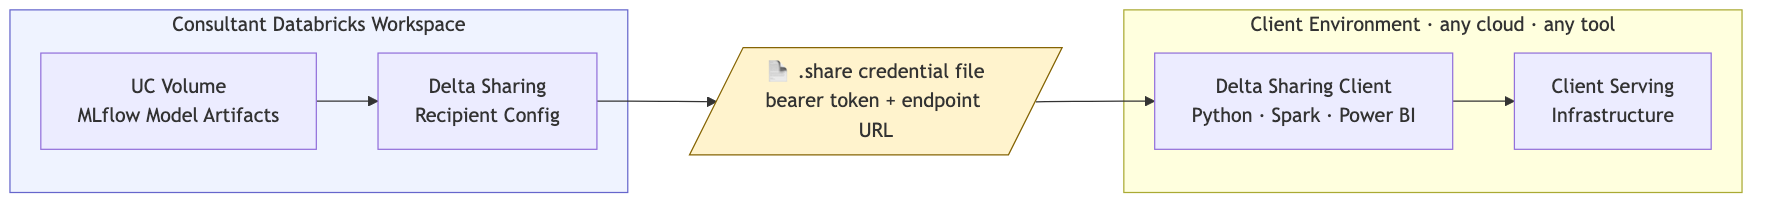

---

## Option 4: MCP server

Wrap the model as a **tool** in a Model Context Protocol (MCP) server so AI agents can invoke it alongside other tools and data sources.

- **Auth required:** Whatever the MCP server implements — API key, mTLS, or nothing if running locally. Databricks authentication is handled *inside* the server and is invisible to the client.
- **Pros:** Native integration with AI agent workflows (Claude, GitHub Copilot, etc.); you control the Databricks credential; highly composable — the client's agent can call the churn model, a CRM lookup, and a Slack notification in the same workflow
- **Cons:** Niche today — requires the client to be running MCP-compatible agents; under the hood it's still a REST call with an additional protocol layer
- **Best for:** Clients already building agentic workflows who want the model as a callable tool; a forward-looking delivery pattern worth discussing even if it's not the immediate answer

> **Where this is going:** As analysts shift from writing SQL to prompting AI assistants, MCP becomes the natural integration layer for ML models. The question of how you expose a model to a client may increasingly mean "what does the MCP tool spec look like" rather than "what's the API endpoint."


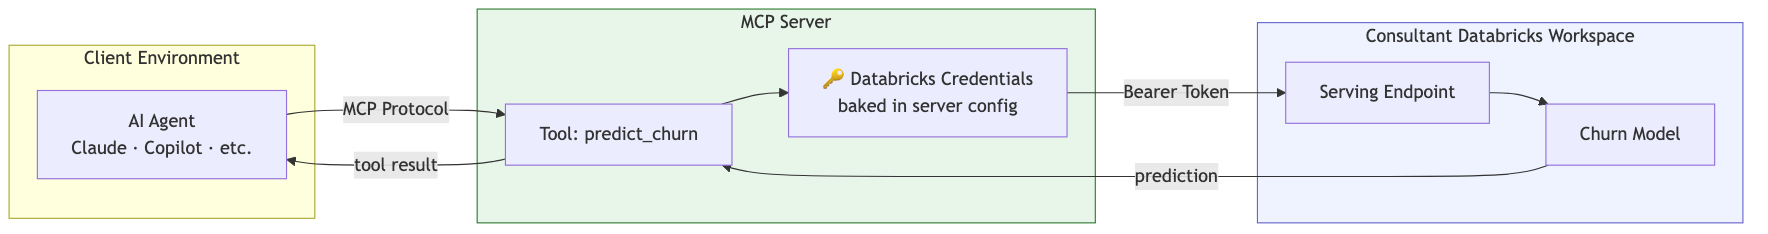

---

## Option 5: Databricks Apps (with a UI)

Wrap the serving endpoint in a web application (Streamlit, Dash, Gradio) that business users access through a browser — no API knowledge needed.

- **Auth required:** **Databricks workspace access** — apps sit behind Databricks OAuth. The client must be provisioned as workspace members or guest users. This is the highest-friction option for external clients.
- **Pros:** Accessible to non-technical business stakeholders; can embed explanations (like the LLM explainer from Session 1), charts, and feedback loops; no integration work on the client side
- **Cons:** Client must have Databricks workspace access; you're now maintaining a UI application in addition to the model; client data still passes through your infrastructure
- **Best for:** When the end users are business stakeholders (CRM team, customer success managers) who will never use an API; internal tooling for a client that already uses Databricks


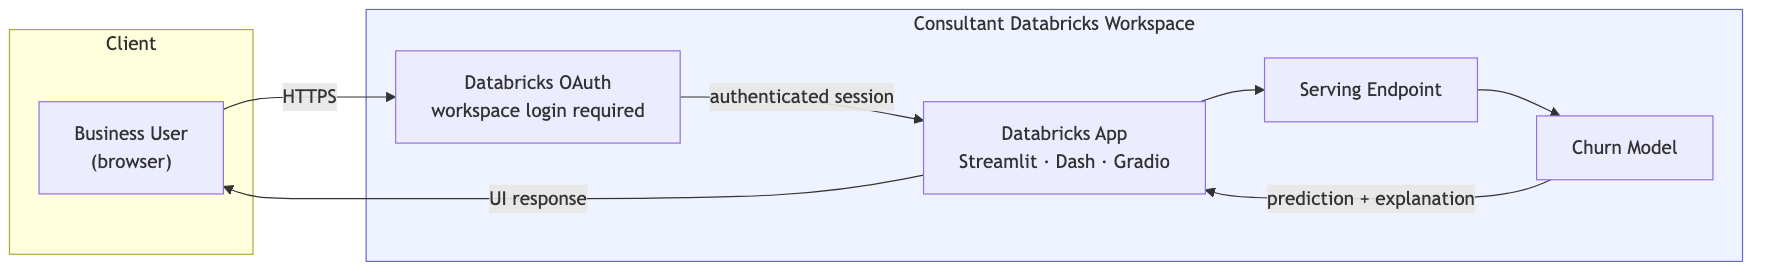

---

## Option 6: Unity Catalog cross-workspace sharing

Grant the client direct access to the registered model in your Unity Catalog. They reference it from their own Databricks workspace as if it were in their own registry.

- **Auth required:** **Client must be a Databricks customer with their own workspace.** Set up via UC recipient management — Databricks-to-Databricks identity, no credential files to manage.
- **Pros:** Cleanest governance story; full lineage and audit trail on both sides; client can pin to `@champion` and always receive your latest promoted version with no coordination overhead; no artifact transfer
- **Cons:** Hard requirement — client must run Databricks; not applicable otherwise
- **Best for:** Enterprise clients who are already Databricks customers; long-term partnerships where the client will eventually operationalize and own the model themselves


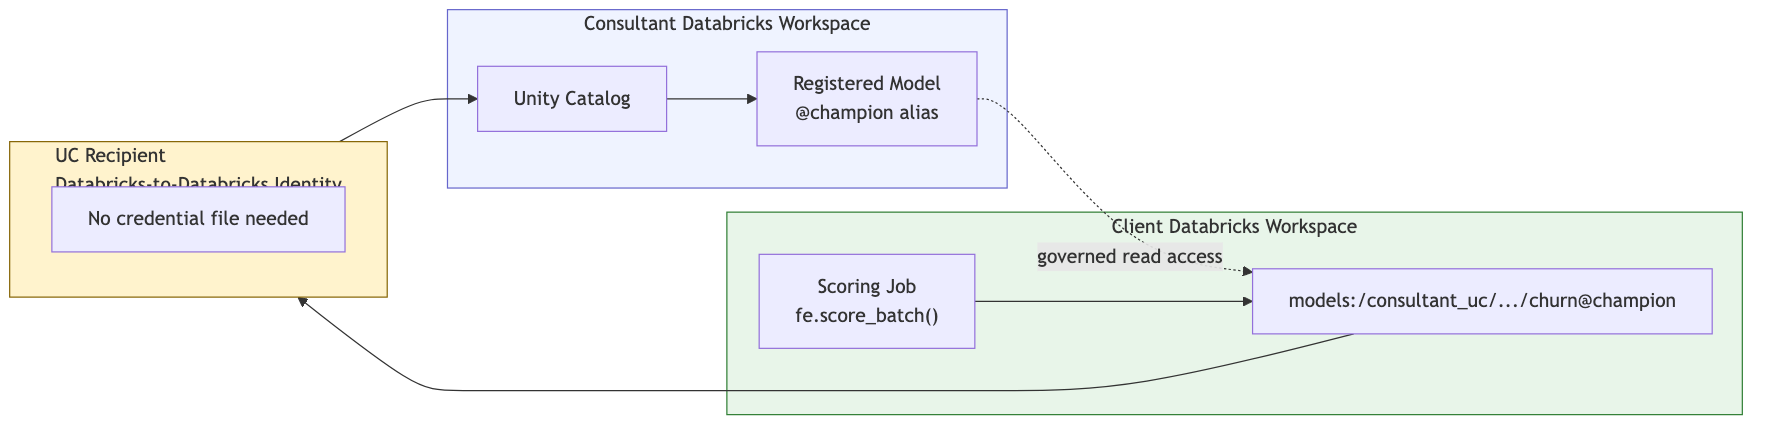

---

## The Key Trade-off: Who Owns the Infrastructure?

| | You run the model | Client runs the model |
|---|---|---|
| **No Databricks account needed** | REST API, MCP server | Pickle / MLflow export, Delta Sharing |
| **Databricks account required** | Databricks Apps | UC cross-workspace |

**Three questions that drive the decision:**

1. **Is the engagement ongoing or a one-time delivery?**  
   Ongoing → REST API or Apps. One-time delivery → Delta Sharing or export.

2. **Does client data need to stay in their environment?**  
   If yes (healthcare, financial services, GDPR) → eliminate REST API and Apps. Delta Sharing or UC cross-workspace.

3. **Is the client a Databricks customer?**  
   If yes → UC cross-workspace is the cleanest option and worth leading with.

---

## Discussion Questions

- For the telco client in this scenario, which approach would you recommend and why?
- How does GDPR, HIPAA, or industry-specific data residency change your answer?
- Which option gives the client the most autonomy after the engagement ends? Which gives you the most control?
- The `@champion` alias means you can promote a new model version without changing the client's integration. Is that a feature or a risk? Who should approve a champion promotion?
- Where does MCP fit in a world where client analysts are increasingly using AI assistants as their primary interface to data?
- What does a complete "client handover package" look like beyond the model itself? *(Think: access, documentation, runbooks, training, on-call rotation.)*

---

## Workshop Complete

✅ **Congratulations** — you've completed the Production-Ready ML workshop.

**Session 1** covered the model development lifecycle:
- Data exploration and feature engineering
- Modular, testable ML code
- MLflow experiment tracking
- Unity Catalog model registration and aliasing
- Serving endpoint deployment with AI Gateway
- LLM-powered explanations with a versioned prompt registry

**Session 2** covered the operational lifecycle:
- CI/CD pipeline with automated retraining and deployment gates
- Drift simulation and monitoring
- Alerting on model degradation
- Canary and A/B deployment patterns
- Incident response runbook
- Client delivery options

The patterns here — aliased model versions, automated quality gates, drift-triggered retraining, governed sharing — are the same patterns that separate a notebook that works once from a system that works reliably in production.